Importing libraries and Modells 

In [29]:
import sys

sys.path.append("..")

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 
from sklearn.decomposition import PCA 
from sklearn.metrics import silhouette_score
from backend.app.ml.preprocessing import prepare_data
import backend.app.ml.preprocessing as preprocessing
import importlib

importlib.reload(preprocessing)

<module 'backend.app.ml.preprocessing' from 'c:\\Users\\jarll\\Desktop\\repos\\Predictor\\models\\..\\backend\\app\\ml\\preprocessing.py'>

Import CSV file and print the data

In [ ]:
FILE_PATH = "../dataset/all_zones_complete_2025.csv"

df = pd.read_csv(FILE_PATH)
df = preprocessing.prepare_data(df)

# df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
# df["timestamp_local"] = df["timestamp"].dt.tz_convert("Europe/Stockholm")

print(f"Inläst: {df.shape[0]} rader, {df.shape[1]} kolumner")

Inläst: 35040 rader, 14 kolumner


In [32]:
# Välj relevanta features för klustring 

FEATURES = [
    "spot_price_eur_mwh",
    "temperature_c",
    "wind_speed_kmh",
    "hour",
    "month",
    "price_lag_24"
]

# Rensa alla icke nummer 
df_clean = df.dropna(subset=FEATURES).copy().reset_index(drop=True)

X = df_clean[FEATURES]
print(f"Rader efter pipeline och dropna: {X.shape[0]}, Feature: {X.shape[1]}")

Rader efter pipeline och dropna: 34944, Feature: 6


In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\jarll\AppData\Local\Temp\ipykernel_38728\1697948768.py:14: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  np.abs(np.cross(p2 - p1, p1 - np.array([k_val, inert_val])))


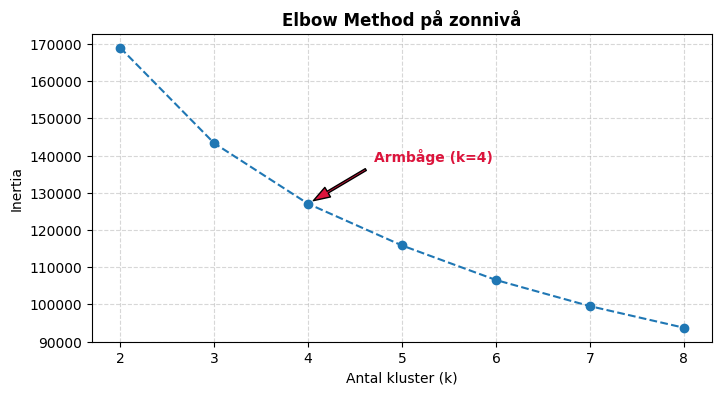

In [34]:
# Beräkna Inertia för k = 2 till 8
k_range = list(range(2, 9))
inertia = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Hitta armbågen geometriskt
p1 = np.array([k_range[0], inertia[0]])
p2 = np.array([k_range[-1], inertia[-1]])
distances = [
    np.abs(np.cross(p2 - p1, p1 - np.array([k_val, inert_val])))
    / np.linalg.norm(p2 - p1)
    for k_val, inert_val in zip(k_range, inertia)
]
elbow_k = k_range[int(np.argmax(distances))]
elbow_inertia = inertia[int(np.argmax(distances))]

# Plotta
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker="o", linestyle="--", color="#1f77b4")
plt.annotate(
    f"Armbåge (k={elbow_k})",
    xy=(elbow_k, elbow_inertia),
    xytext=(elbow_k + 0.7, elbow_inertia + (max(inertia) - min(inertia)) * 0.15),
    arrowprops=dict(facecolor="crimson", shrink=0.08, width=1.5, headwidth=8),
    fontweight="bold",
    color="crimson",
)
plt.title("Elbow Method på zonnivå", fontweight="bold")
plt.xlabel("Antal kluster (k)")
plt.ylabel("Inertia")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Träna modellen 

In [35]:
FINAL_K = elbow_k  # eller sätt manuellt t.ex. 4

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(X_scaled)

# 1. Klusterprofiler (medelvärden för features)
print("--- Klusterprofiler (Medelvärden) ---")
display(df_clean.groupby("cluster")[FEATURES].mean().round(2))

# 2. Korsanalys: Hur många timmar spenderar respektive zon i respektive kluster?
print("\n--- Fördelning av kluster per zon (procentuell) ---")
zone_cluster_distribution = (
    pd.crosstab(df_clean["zone"], df_clean["cluster"], normalize="index") * 100
).round(1)
display(zone_cluster_distribution)

--- Klusterprofiler (Medelvärden) ---


,spot_price_eur_mwh,temperature_c,wind_speed_kmh,hour,month,price_lag_24
cluster,,,,,,
0,20.59,0.34,13.98,10.65,2.48,20.55
1,18.69,13.49,15.14,16.55,7.63,20.05
2,25.09,8.22,11.95,4.95,8.75,23.57
3,104.47,5.09,11.77,14.21,6.92,103.46



--- Fördelning av kluster per zon (procentuell) ---


cluster,0,1,2,3
zone,,,,
SE1,32.6,32.6,28.9,6.0
SE2,30.4,33.3,30.6,5.7
SE3,20.7,30.0,27.8,21.6
SE4,15.8,28.4,22.9,32.9


Spara modellen

In [ ]:
import joblib

# 1. Spara tränad modell och scaler
joblib.dump(kmeans, "kmeans_zone_model.pkl")
joblib.dump(scaler, "scaler_zone.pkl")

# 2. Spara det berikade datasetet med klusteretiketter
OUTPUT_DATASET = "../dataset/all_zones_clustered_long_2025.csv"
df_clean.to_csv(OUTPUT_DATASET, index=False)

print("Modell och scaler sparade:")
print(" - kmeans_zone_model.pkl")
print(" - scaler_zone.pkl")
print(f" - Dataset sparat till: {OUTPUT_DATASET}")

<Figure size 1000x550 with 0 Axes>

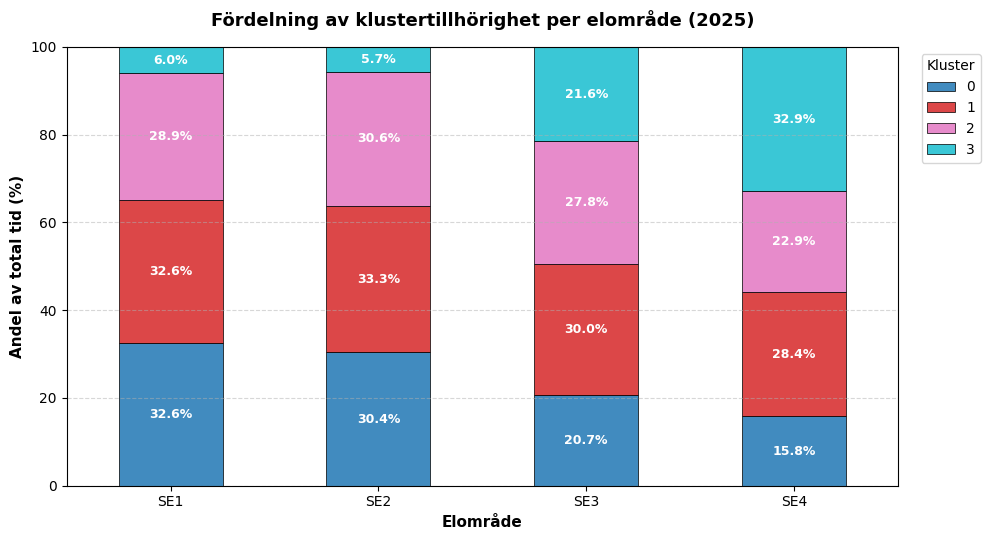

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Beräkna procentuell fördelning per zon och kluster
zone_dist = pd.crosstab(df_clean["zone"], df_clean["cluster"], normalize="index") * 100

# 2. Plotta stapeldiagrammet
plt.figure(figsize=(10, 5.5))
ax = zone_dist.plot(
    kind="bar",
    stacked=True,
    colormap="tab10",
    figsize=(10, 5.5),
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
)

plt.title(
    "Fördelning av klustertillhörighet per elområde (2025)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Elområde", fontsize=11, fontweight="bold")
plt.ylabel("Andel av total tid (%)", fontsize=11, fontweight="bold")
plt.xticks(rotation=0, fontsize=10)
plt.ylim(0, 100)
plt.legend(title="Kluster", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Lägg till procentetiketter inuti staplarna (för segment > 5%)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5.0:
        x, y = p.get_xy()
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="white",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()